In [1]:
import ast
from pathlib import Path

import polars as pl

TIMING_RESULTS = Path("..") / "timing_results"

UNIT_TO_S = {"MILLISECONDS": 1e-3, "SECONDS": 1.0, "NANOSECONDS": 1e-9, "MINUTES": 60.0}

rows = []
for f in sorted(TIMING_RESULTS.glob("*/*/Predictions/*/testResample*.csv")):
    with open(f) as fh:
        header = fh.readline().rstrip("\n").split(",")
        params_line = fh.readline().rstrip("\n")
        result = fh.readline().rstrip("\n").split(",")
    scale = UNIT_TO_S[header[4]]
    try:
        params = ast.literal_eval(params_line)
    except (ValueError, SyntaxError):
        params = {}
    rows.append(
        {
            "run": f.parents[3].name,
            "model": f.parents[2].name,
            "dataset": f.parent.name,
            "resample": int(f.stem.removeprefix("testResample")),
            "n_gpus": params.get("n_gpus"),
            "n_jobs": params.get("n_jobs"),
            "accuracy": float(result[0]),
            "fit_s": float(result[1]) * scale,
            "predict_s": float(result[2]) * scale,
        }
    )

df = pl.DataFrame(rows, infer_schema_length=None)
print(df.group_by(["run", "model", "n_jobs", "n_gpus"]).len("n_results").sort("run", "model"))
df.head()

shape: (17, 5)
┌──────────────────────────┬─────────────────────────────────┬────────┬────────┬───────────┐
│ run                      ┆ model                           ┆ n_jobs ┆ n_gpus ┆ n_results │
│ ---                      ┆ ---                             ┆ ---    ┆ ---    ┆ ---       │
│ str                      ┆ str                             ┆ i64    ┆ i64    ┆ u32       │
╞══════════════════════════╪═════════════════════════════════╪════════╪════════╪═══════════╡
│ mrhydra_16cpu            ┆ MultiRocketHydra                ┆ 16     ┆ null   ┆ 112       │
│ mrhydra_4cpu             ┆ MultiRocketHydra                ┆ 4      ┆ null   ┆ 112       │
│ mrhydra_8cpu             ┆ MultiRocketHydra                ┆ 8      ┆ null   ┆ 112       │
│ tscglue-high_16cpu       ┆ TSCGlueEnhancedV4-High-LogLoss… ┆ 16     ┆ 0      ┆ 111       │
│ tscglue-high_16cpu_gpu   ┆ TSCGlueEnhancedV4-High-LogLoss… ┆ 16     ┆ 1      ┆ 112       │
│ …                        ┆ …                         

run,model,dataset,resample,n_gpus,n_jobs,accuracy,fit_s,predict_s
str,str,str,i64,i64,i64,f64,f64,f64
"""mrhydra_16cpu""","""MultiRocketHydra""","""ACSF1""",0,null,16,0.88,0.914,0.632
"""mrhydra_16cpu""","""MultiRocketHydra""","""Adiac""",0,null,16,0.84399,0.611,0.316
"""mrhydra_16cpu""","""MultiRocketHydra""","""ArrowHead""",0,null,16,0.862857,0.109,0.307
"""mrhydra_16cpu""","""MultiRocketHydra""","""BME""",0,null,16,1.0,0.065,0.092
"""mrhydra_16cpu""","""MultiRocketHydra""","""Beef""",0,null,16,0.766667,0.146,0.061


In [2]:
df = df.with_columns(
    (
        pl.col("model")
        + "  [n_jobs="
        + pl.col("n_jobs").cast(pl.String).fill_null("-")
        + ", n_gpus="
        + pl.col("n_gpus").cast(pl.String).fill_null("-")
        + "]"
    ).alias("config")
)
df["config"].value_counts()

config,count
str,u32
"""MultiRocketHydra [n_jobs=4, n…",112
"""TSCGlueEnhancedV4-Low-LogLoss-…",112
"""MultiRocketHydra [n_jobs=8, n…",112
"""TSCGlueEnhancedV4-Medium-LogLo…",7
"""TSCGlueEnhancedV4-Low-LogLoss-…",112
…,…
"""TSCGlueEnhancedV4-Medium-LogLo…",112
"""TSCGlueEnhancedV4-High-LogLoss…",75
"""TSCGlueEnhancedV4-High-LogLoss…",112


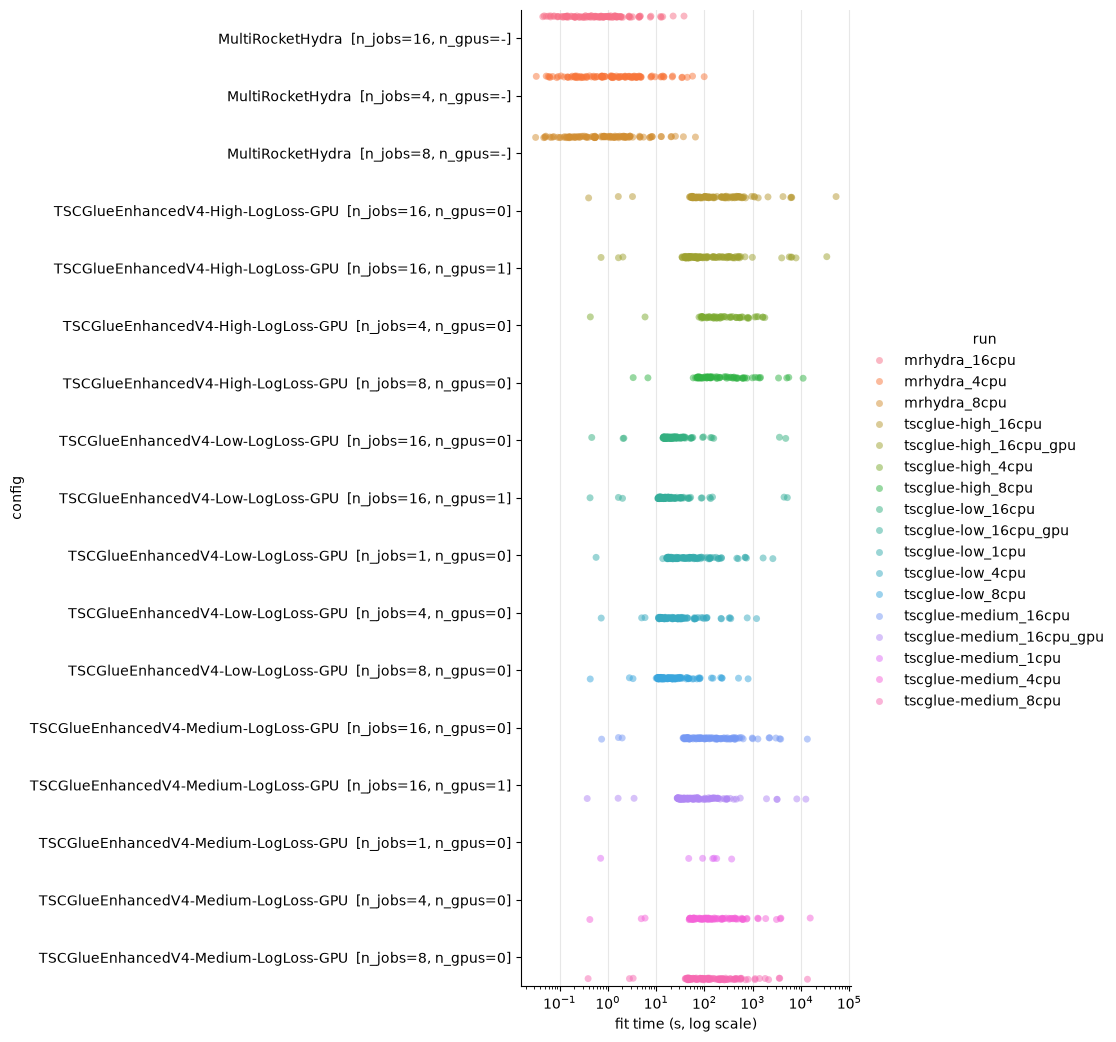

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.catplot(
    data=df,
    x="fit_s",
    y="config",
    hue="run",
    kind="strip",
    height=2 + 0.5 * df["config"].n_unique(),
    aspect=10 / (2 + 0.5 * df["config"].n_unique()),
    alpha=0.5,
    jitter=0.25,
    dodge=True,
)
g.ax.set_xscale("log")
g.ax.set_xlabel("fit time (s, log scale)")
g.ax.grid(axis="x", alpha=0.3)
plt.show()


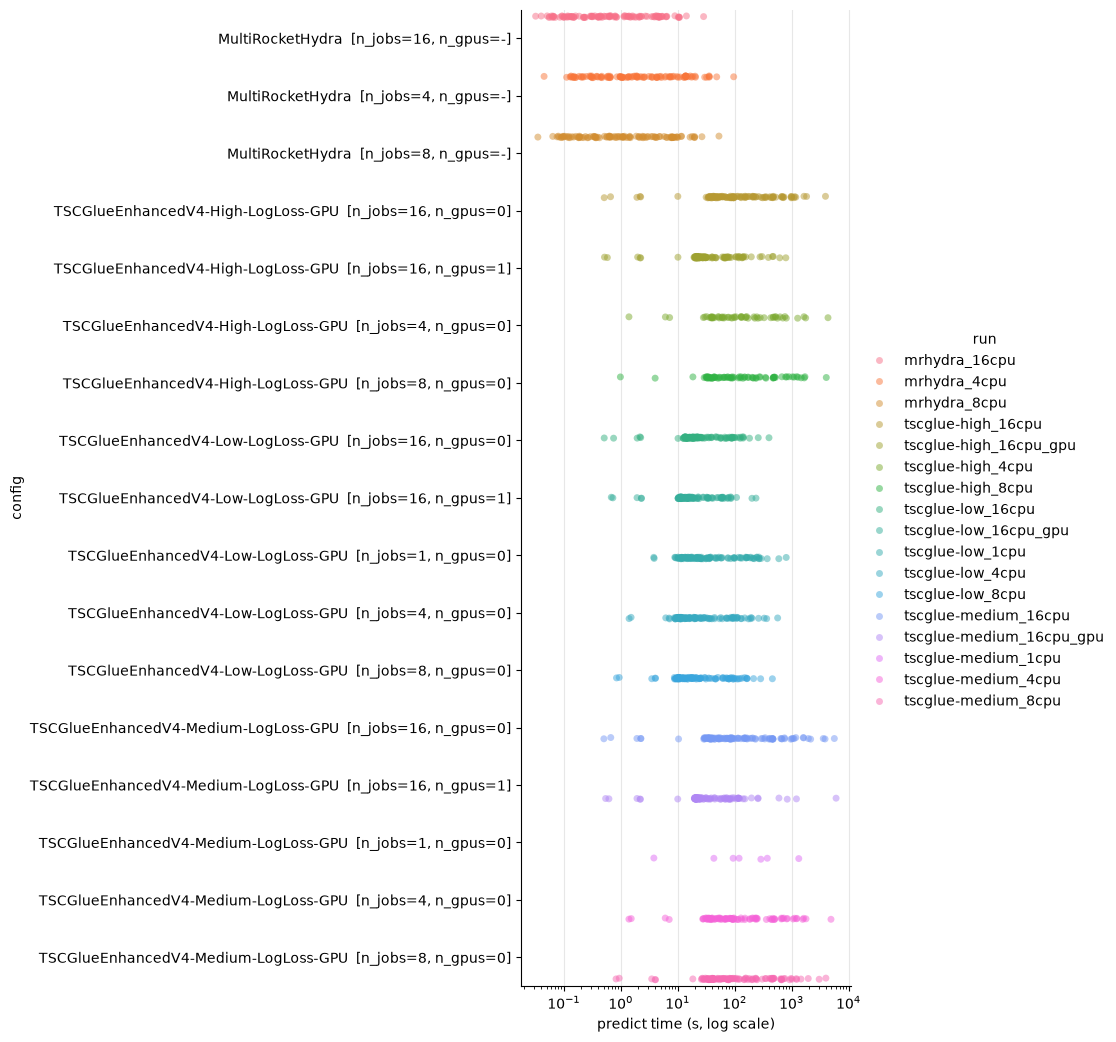

In [4]:
g = sns.catplot(
    data=df,
    x="predict_s",
    y="config",
    hue="run",
    kind="strip",
    height=2 + 0.5 * df["config"].n_unique(),
    aspect=10 / (2 + 0.5 * df["config"].n_unique()),
    alpha=0.5,
    jitter=0.25,
    dodge=True,
)
g.ax.set_xscale("log")
g.ax.set_xlabel("predict time (s, log scale)")
g.ax.grid(axis="x", alpha=0.3)
plt.show()


In [5]:
df.group_by(["model", "n_jobs", "n_gpus"]).agg(
    pl.len().alias("n"),
    pl.col("fit_s").mean().alias("fit_s_mean"),
    pl.col("fit_s").median().alias("fit_s_median"),
    pl.col("fit_s").min().alias("fit_s_min"),
    pl.col("fit_s").max().alias("fit_s_max"),
    pl.col("predict_s").mean().alias("predict_s_mean"),
    pl.col("predict_s").median().alias("predict_s_median"),
    pl.col("predict_s").min().alias("predict_s_min"),
    pl.col("predict_s").max().alias("predict_s_max"),
    pl.col("accuracy").mean().alias("accuracy_mean"),
).sort("model")


model,n_jobs,n_gpus,n,fit_s_mean,fit_s_median,fit_s_min,fit_s_max,predict_s_mean,predict_s_median,predict_s_min,predict_s_max,accuracy_mean
str,i64,i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""MultiRocketHydra""",4,null,112,4.899464,1.1975,0.033,98.848,6.69592,1.714,0.045,96.08,0.868977
"""MultiRocketHydra""",8,null,112,3.019723,0.818,0.032,65.14,3.806375,1.0165,0.035,52.968,0.868977
"""MultiRocketHydra""",16,null,112,1.891741,0.6345,0.045,37.762,2.141196,0.6265,0.032,28.473,0.868977
"""TSCGlueEnhancedV4-High-LogLoss…",16,0,111,935.887036,147.051,0.4,53174.157,283.784387,94.759,0.512,3932.591,0.87792
"""TSCGlueEnhancedV4-High-LogLoss…",8,0,75,607.977427,139.738,3.345,11044.75,342.82988,97.079,0.985,4064.069,0.874351
…,…,…,…,…,…,…,…,…,…,…,…,…
"""TSCGlueEnhancedV4-Medium-LogLo…",16,0,112,424.136295,105.6865,0.743,13522.829,365.096214,83.2335,0.505,5625.734,0.878418
"""TSCGlueEnhancedV4-Medium-LogLo…",8,0,112,408.979634,115.2065,0.39,13610.176,284.833304,76.756,0.826,3997.371,0.87842
"""TSCGlueEnhancedV4-Medium-LogLo…",4,0,91,512.972978,123.321,0.424,15501.364,312.799692,89.653,1.391,4912.434,0.877584


In [6]:
# CPU scaling of fit time, paired per dataset against the 4-CPU run of the same model.
# Pairing matters: the 4/8-CPU runs are incomplete for some models, so raw per-config
# means would compare different dataset subsets.
cpu = df.filter((pl.col("n_gpus") == 0) | pl.col("n_gpus").is_null())
base_4cpu = cpu.filter(pl.col("n_jobs") == 4).select(
    "model", "dataset", "resample", pl.col("fit_s").alias("fit_s_4cpu")
)
scaling = cpu.join(base_4cpu, on=["model", "dataset", "resample"], how="inner").with_columns(
    (pl.col("fit_s_4cpu") / pl.col("fit_s")).alias("speedup_vs_4cpu"),
    pl.col("model")
    .str.replace("TSCGlueEnhancedV4-", "")
    .str.replace("-LogLoss-GPU", "")
    .alias("model_short"),
)

scaling.group_by(["model", "n_jobs"]).agg(
    pl.col("dataset").n_unique().alias("n_datasets"),
    pl.col("fit_s").median().alias("fit_s_median"),
    pl.col("fit_s").sum().alias("fit_s_total"),
    pl.col("fit_s_4cpu").sum().alias("fit_s_total_4cpu"),
    pl.col("speedup_vs_4cpu").median().alias("speedup_median"),
    (pl.col("speedup_vs_4cpu") < 0.95).mean().alias("frac_slower_than_4cpu"),
).sort("model", "n_jobs")

model,n_jobs,n_datasets,fit_s_median,fit_s_total,fit_s_total_4cpu,speedup_median,frac_slower_than_4cpu
str,i64,u32,f64,f64,f64,f64,f64
"""MultiRocketHydra""",4,112,1.1975,548.74,548.74,1.0,0.0
"""MultiRocketHydra""",8,112,0.818,338.209,548.74,1.539895,0.017857
"""MultiRocketHydra""",16,112,0.6345,211.875,548.74,2.022377,0.035714
"""TSCGlueEnhancedV4-High-LogLoss…",4,58,211.5035,22533.343,22533.343,1.0,0.0
"""TSCGlueEnhancedV4-High-LogLoss…",8,37,178.789,11784.849,14813.16,1.235696,0.0
…,…,…,…,…,…,…,…
"""TSCGlueEnhancedV4-Low-LogLoss-…",16,112,20.111,11363.578,6475.463,1.102148,0.348214
"""TSCGlueEnhancedV4-Medium-LogLo…",1,5,158.321,796.149,1084.504,1.169947,0.4
"""TSCGlueEnhancedV4-Medium-LogLo…",4,91,123.321,46680.541,46680.541,1.0,0.0


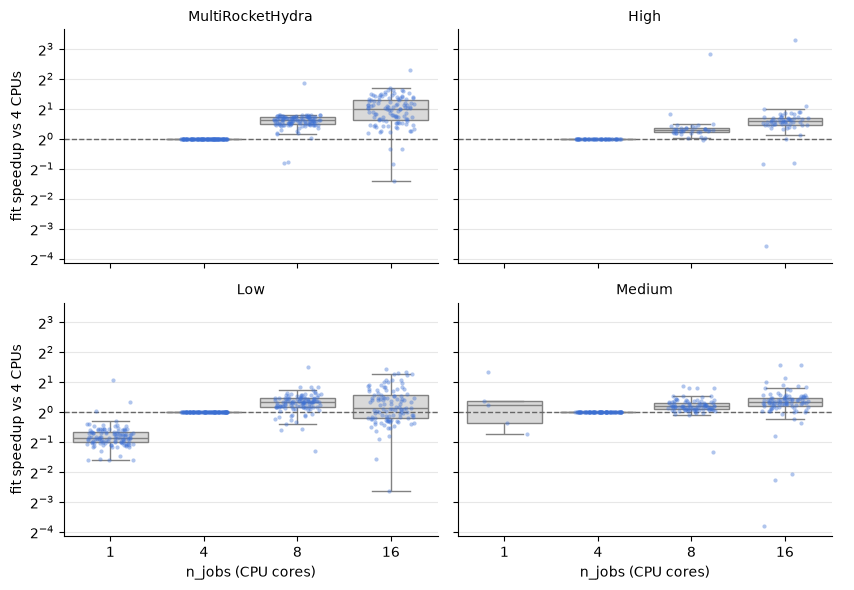

In [7]:
g = sns.catplot(
    data=scaling,
    x="n_jobs",
    y="speedup_vs_4cpu",
    col="model_short",
    kind="box",
    col_wrap=2,
    height=3,
    aspect=1.4,
    color="0.85",
    linewidth=1,
    fliersize=0,
)
for model_short, ax in g.axes_dict.items():
    sns.stripplot(
        data=scaling.filter(pl.col("model_short") == model_short),
        x="n_jobs",
        y="speedup_vs_4cpu",
        ax=ax,
        color="#3b6fd4",
        alpha=0.4,
        size=3,
        jitter=0.25,
    )
    ax.axhline(1.0, color="0.4", lw=1, ls="--")
    ax.set_yscale("log", base=2)
    ax.grid(axis="y", alpha=0.3)
g.set_titles("{col_name}")
g.set_axis_labels("n_jobs (CPU cores)", "fit speedup vs 4 CPUs")
plt.show()